In [1]:
import subprocess
import tempfile
import json
import sys
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import torch
import torch.multiprocessing as mp
import argparse
import hashlib
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor
from functools import partial
from collections import defaultdict
import traceback
from matplotlib.markers import MarkerStyle
torch.set_float32_matmul_precision('high')
# Set publication-quality styling
plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 18,
    'axes.titlesize': 20,
    'legend.fontsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'figure.dpi': 150,
})

# --- Arcsin Kernel Function ---
def arcsin_kernel(X: torch.Tensor) -> torch.Tensor:
    """Compute arcsin kernel matrix for inputs X (P, d)."""
    XXT = torch.einsum('ui,vi->uv', X, X) / X.shape[1]
    diag = torch.sqrt((1 + 2 * XXT).diag())
    denom = diag[:, None] * diag[None, :]
    arg = 2 * XXT / denom
    return (2 / torch.pi) * torch.arcsin(arg)

# --- Configuration & Paths ---
import os

import os
print(os.getcwd())
cwd = Path(os.getcwd())
LIB_PATH = Path(os.getcwd()).parent.parent / "lib"
JULIA_SCRIPT = cwd.parent.parent / "julia_lib" / "eos_fcn3erf_hermite.jl"
RESULTS_DIR = cwd / "hermite_activation"
CACHE_DIR = RESULTS_DIR / "analysis_cache"
sys.path.insert(0, str(LIB_PATH))

MAX_GPU_WORKERS = 2   
MAX_CPU_WORKERS = 10  
EPSILON = 0.074

RESULTS_DIR.mkdir(exist_ok=True, parents=True)
CACHE_DIR.mkdir(exist_ok=True, parents=True)

from FCN3Network import FCN3NetworkActivationGeneric


/home/akiva/FCNX-Ensembling/milestones/activation_generic_erf_mf_scaling_convergence


In [2]:
d = 150
n1 = 200
n2 = 200
device = 'cuda:0'
P = 1500
ens = 5
sd = torch.load('/home/akiva/FCNX-Ensembling/milestones/activation_generic_erf_mf_scaling_convergence/hermite_activation/d150_P1500_N200_chi200_kappa0.1/seed0/model_final.pt', map_location="cpu")

model = FCN3NetworkActivationGeneric(
    d=d, n1=n1, n2=n2, P=P, ens=ens, activation="hermite3",
    weight_initialization_variance=(1.0/d, 1.0/n1, 1.0/(n1*n2))
).to(device)
model.load_state_dict({k: v.squeeze(0) if v.ndim > (3 if 'W' in k else 2) else v for k, v in sd.items()}, strict=False)
model.eval()

FCN3NetworkActivationGeneric()

In [3]:
# Project preactivations onto the He3 hermite polynomial
P_total = 50000
x0 = torch.randn(P_total, d).to(device)  # Shape: (P_total, d)
preactivation = model.h1_preactivation(x0)  # Shape: (P_total, n1)
h3 = torch.einsum('ijk,i->jk', preactivation[:,:,:], (x0[:,0]**3 - 3*x0[:,0]) / 6**0.5 / P_total)  # Shape: (P_total, n1)
# h3  = h3.flatten()

print(h3.shape)

torch.Size([5, 200])


In [2]:
np.sort(h3[0,:].detach().cpu().numpy())

NameError: name 'h3' is not defined

In [ ]:
h3[0,:].mean()

tensor(0.0072, device='cuda:0', grad_fn=<MeanBackward0>)

/tmp/ipykernel_1341763/3065786870.py:16: RuntimeWarning: divide by zero encountered in log
  action = -np.log(np.histogram(h3.detach().cpu().numpy()[i,:], bins=40, density=True)[0])


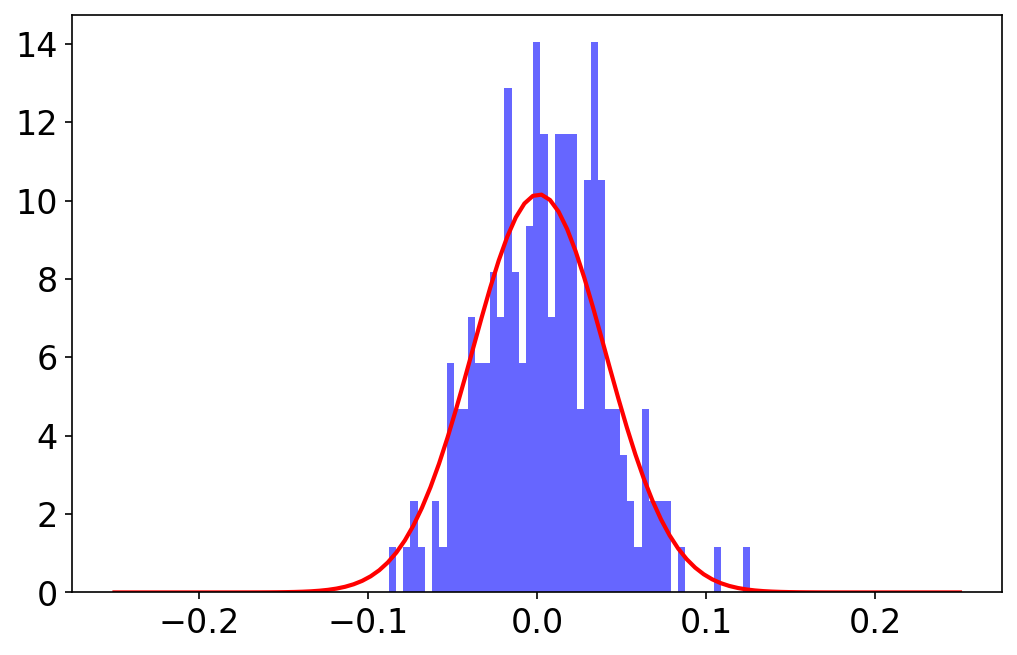

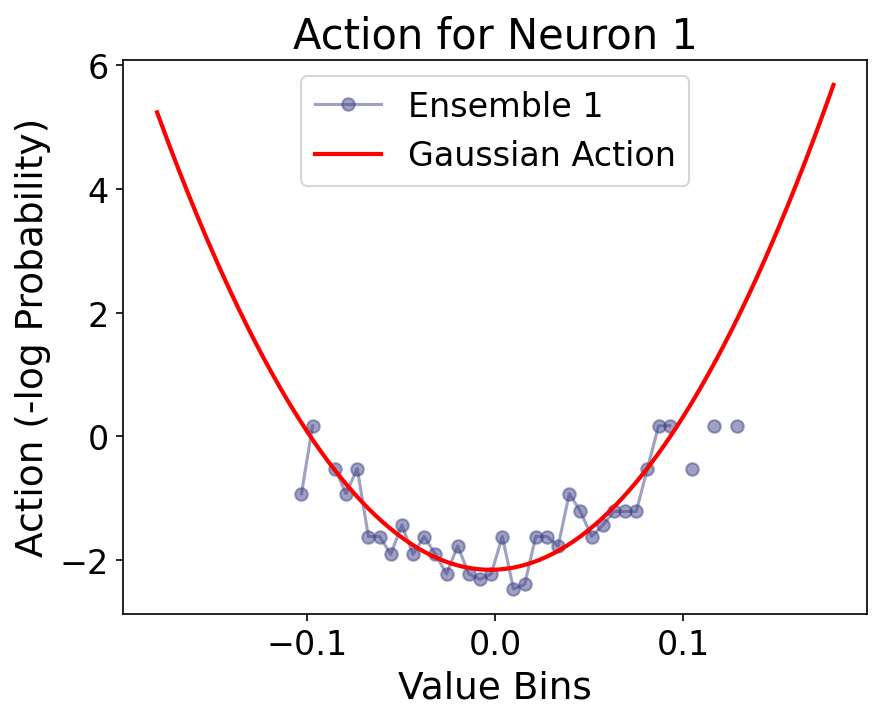

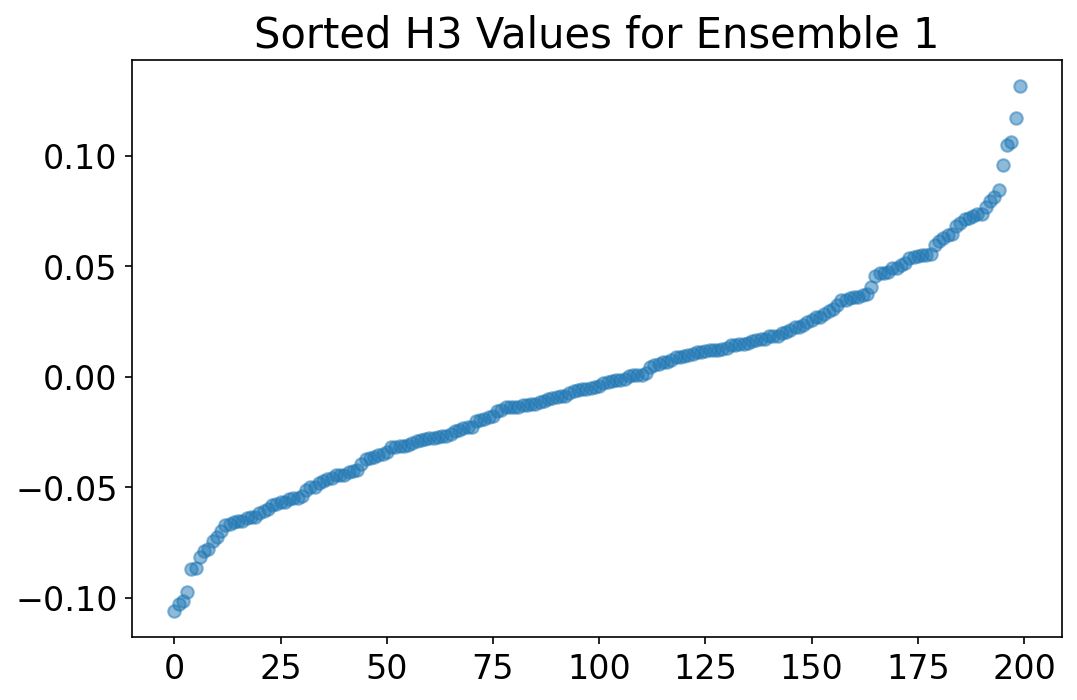

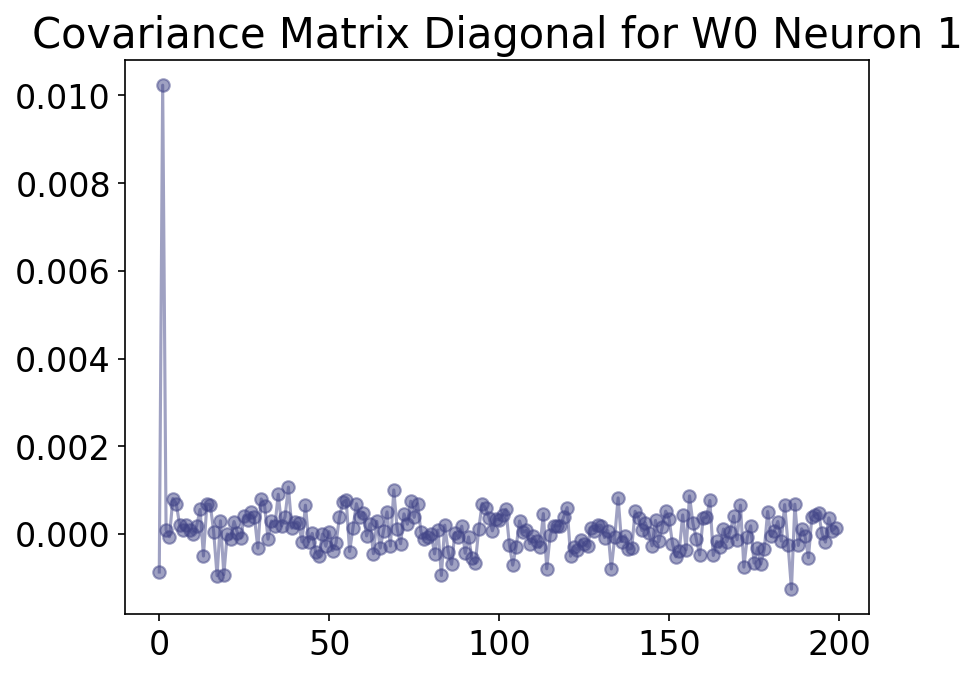

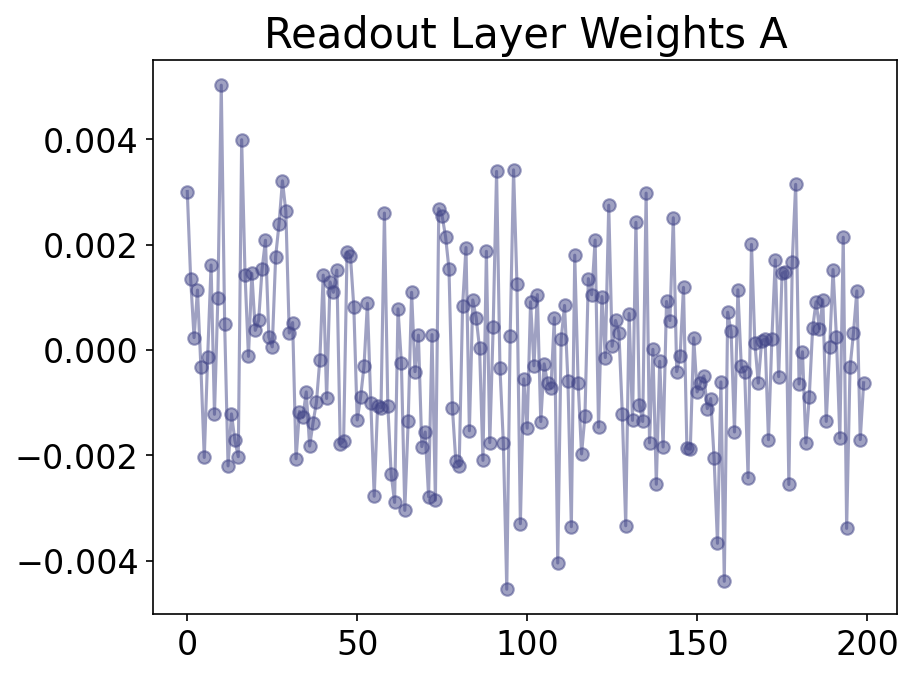

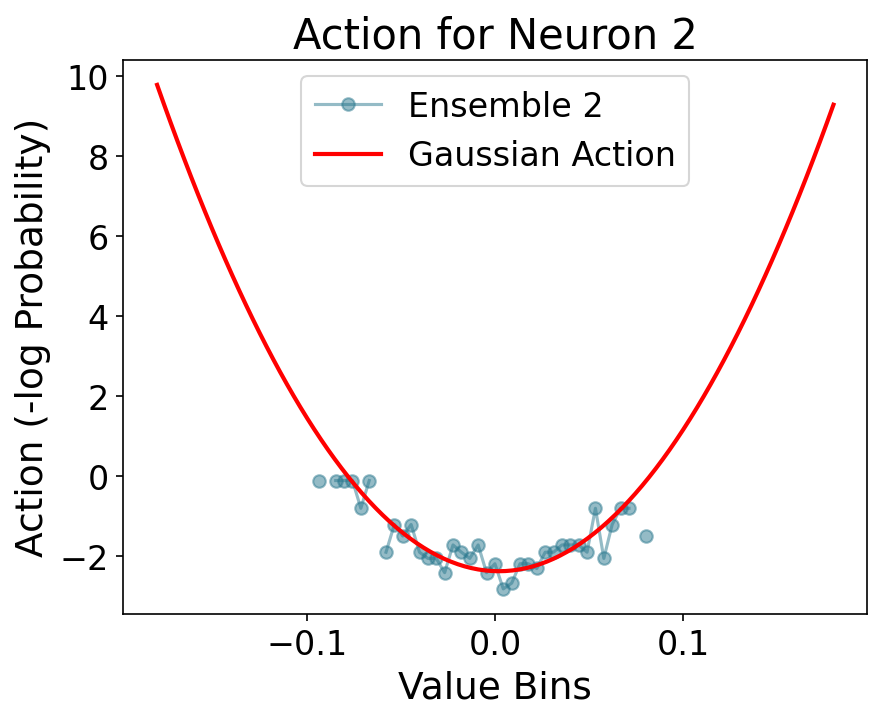

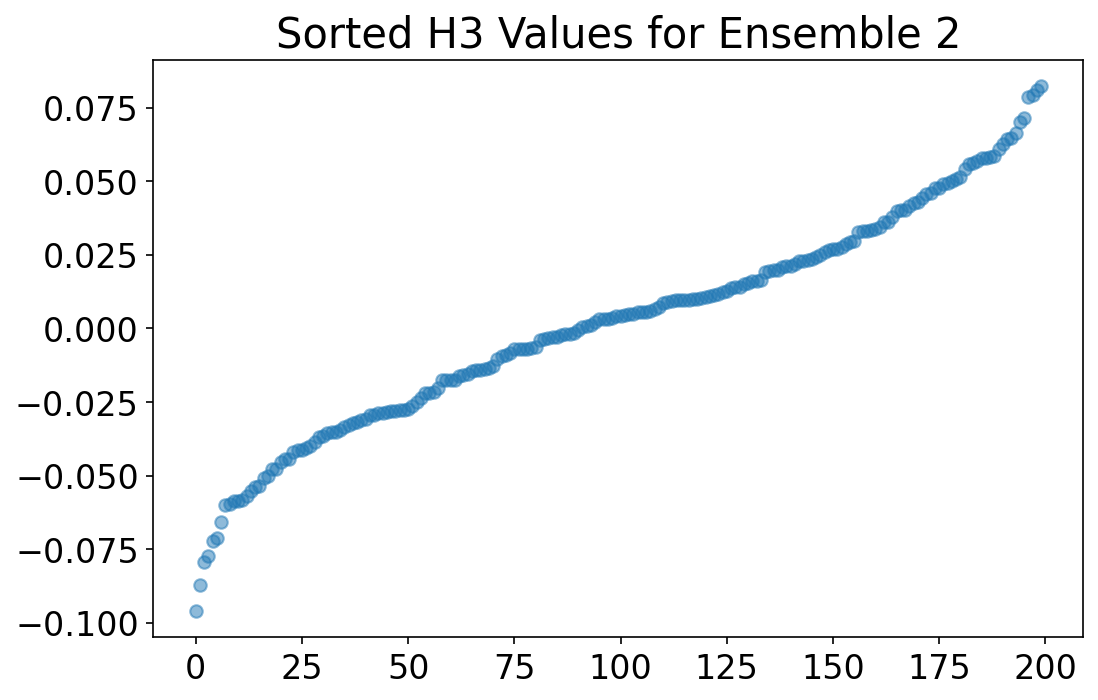

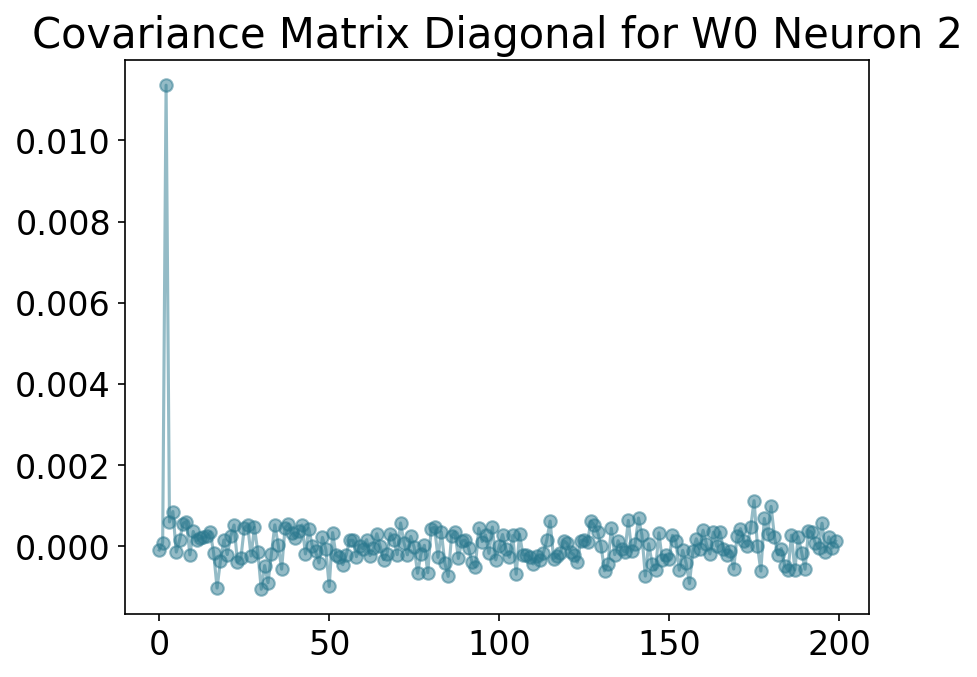

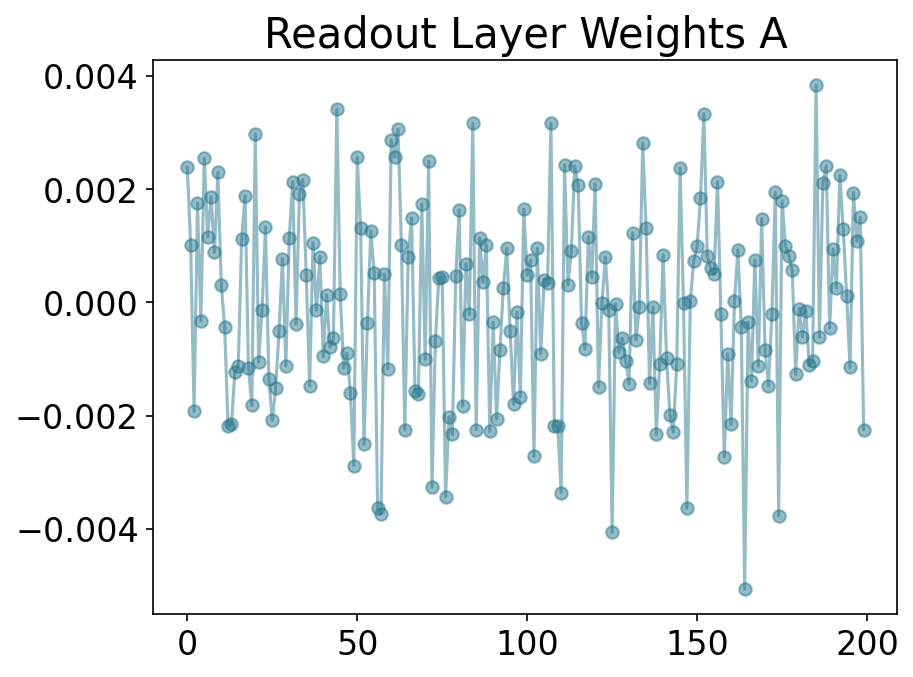

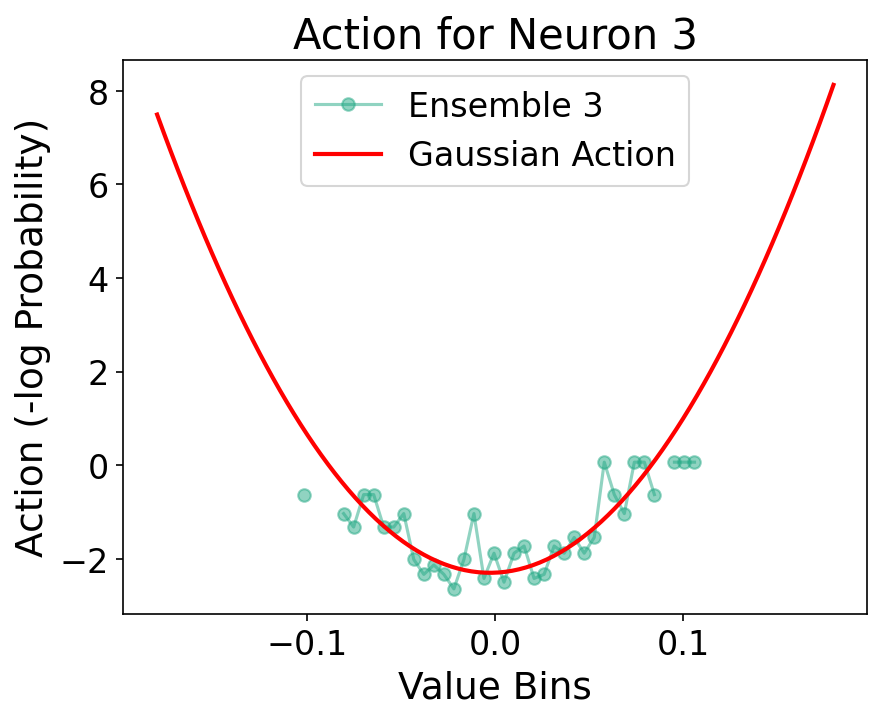

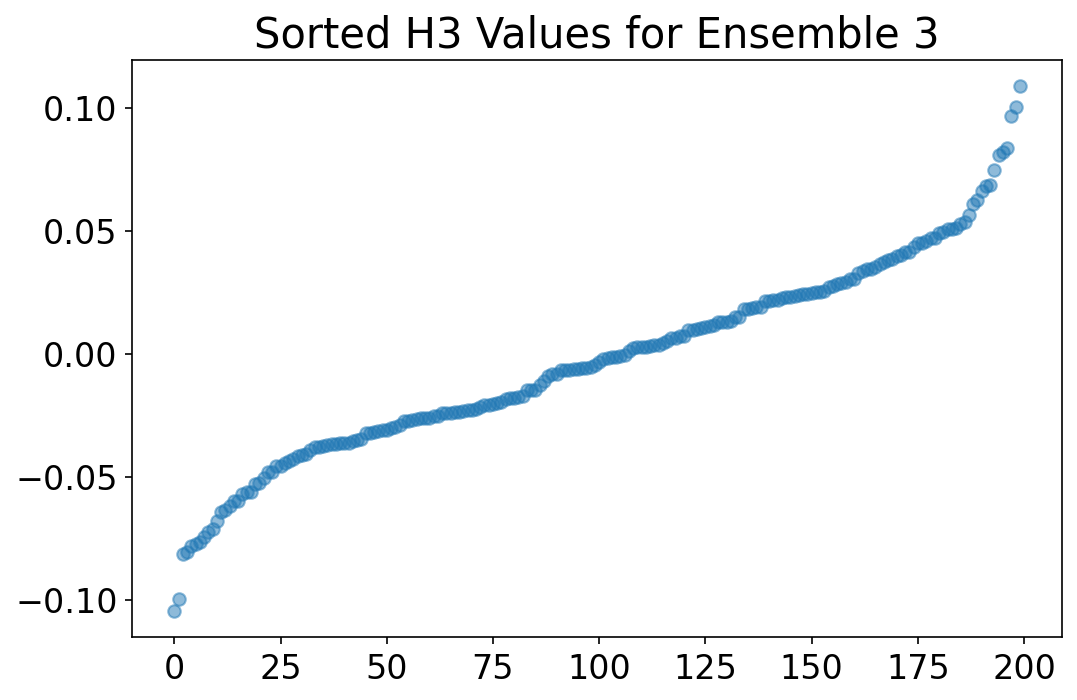

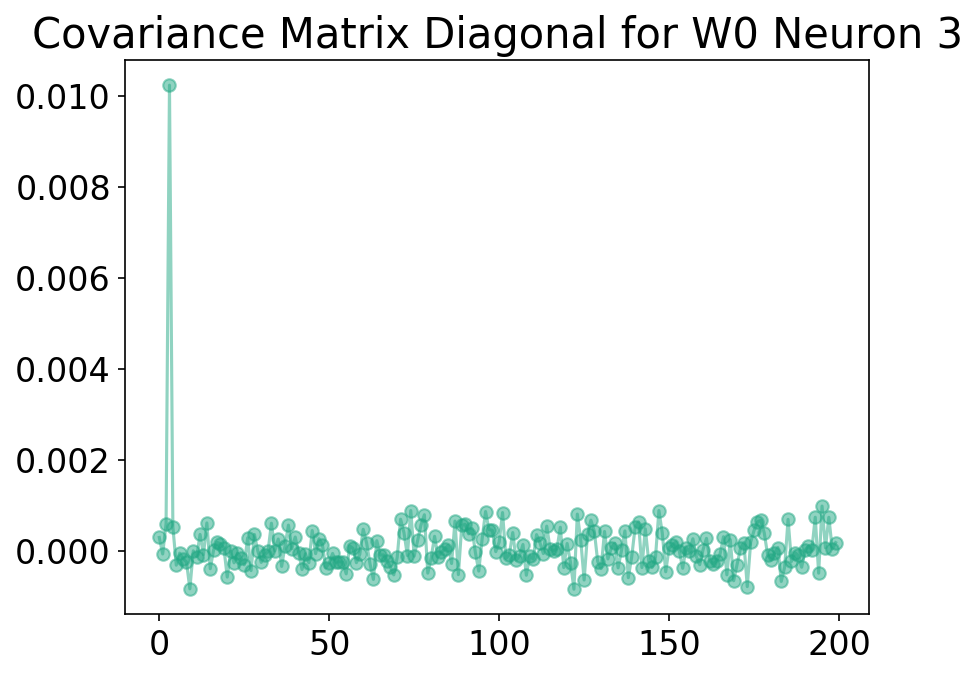

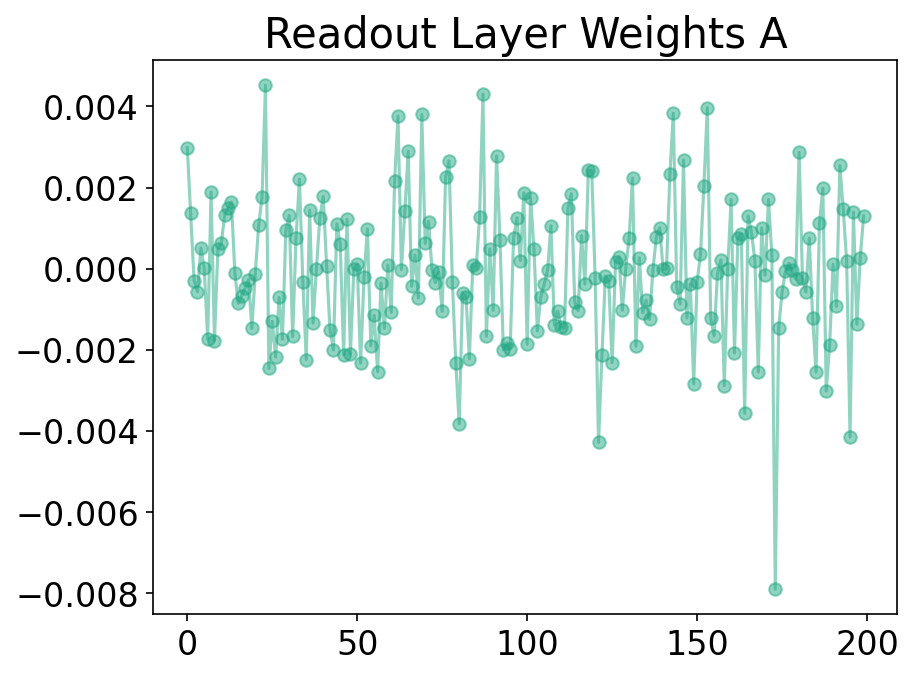

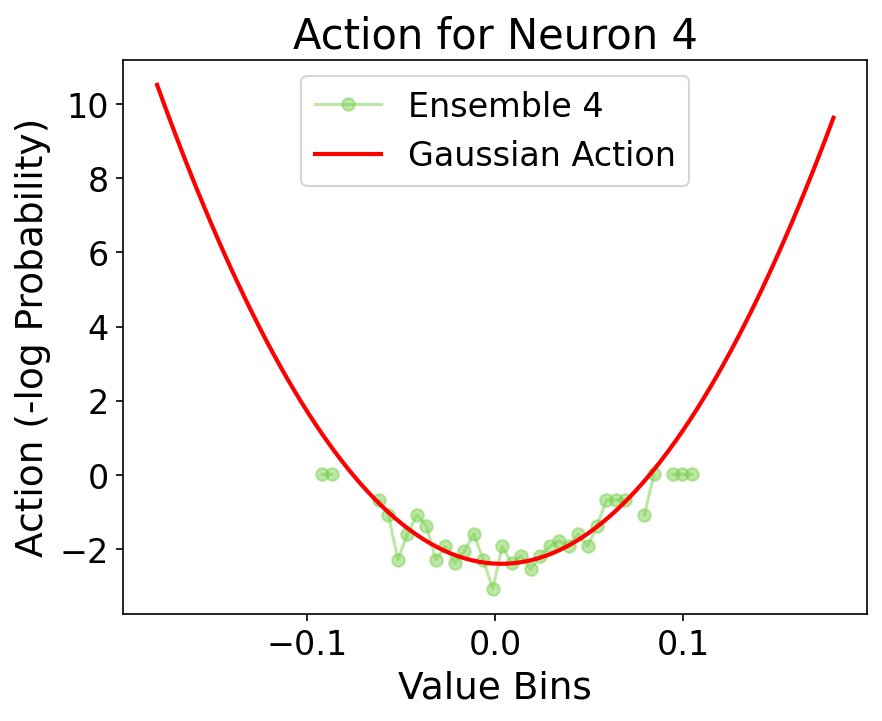

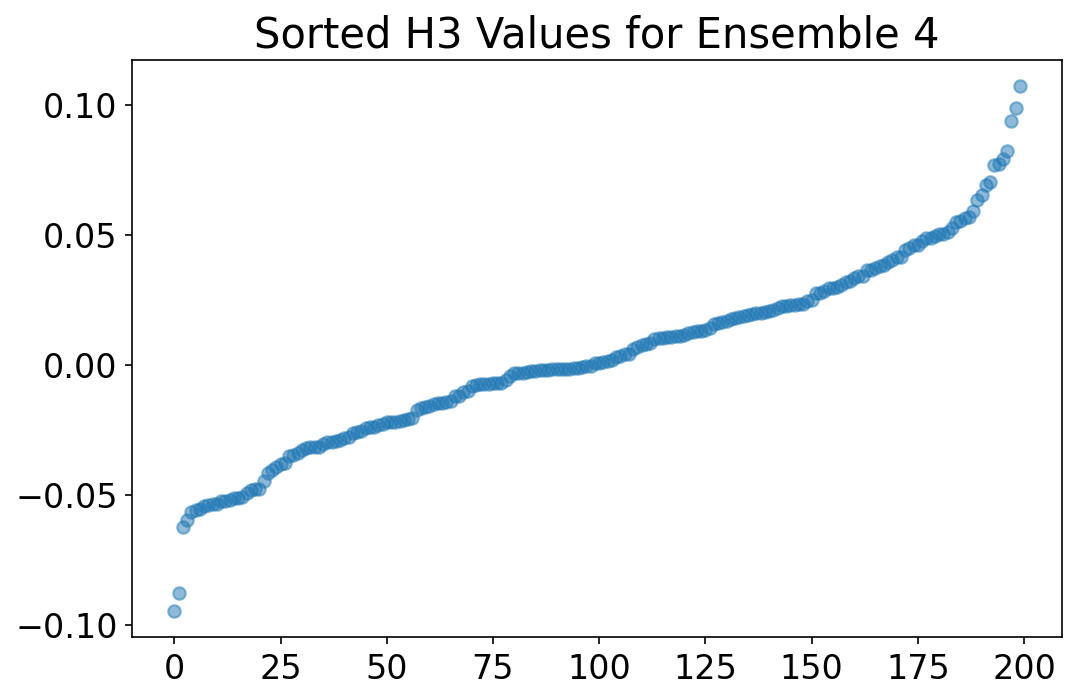

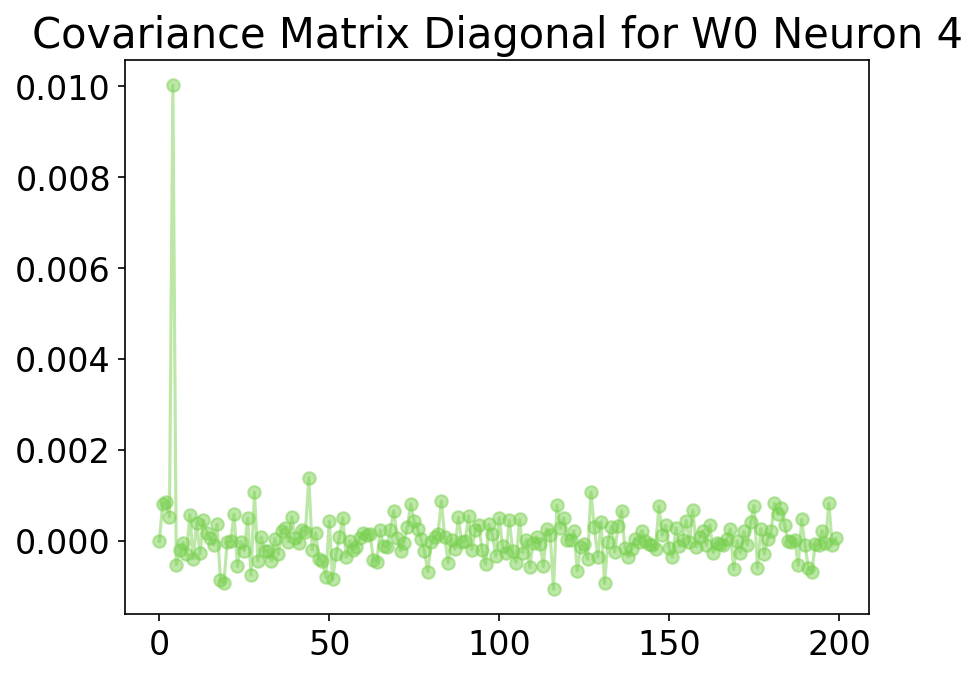

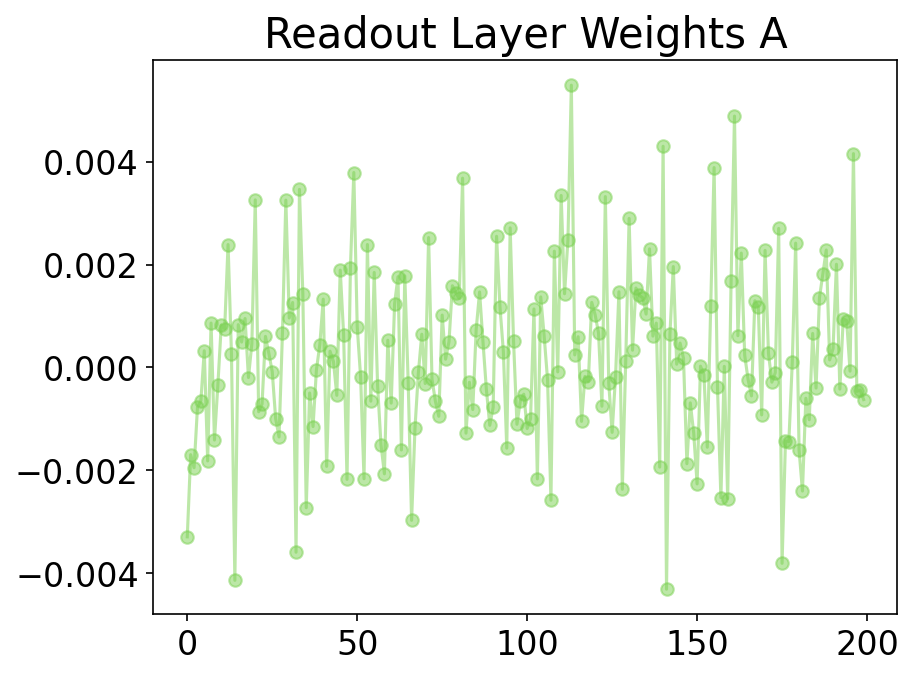

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.hist(h3.detach().cpu().numpy()[0,:], bins=50,linestyle='None', density=True, alpha=0.6, color='b')
# Plot a gaussian for comparison with the variance of h3
h3_variance = h3[:,:].var().item()
x = np.linspace(-0.25, 0.25, 100)
y = 1 / np.sqrt(2 * np.pi * h3_variance) * np.exp(-0.5 * (x - h3[:,:].mean().item())**2 / h3_variance)
plt.plot(x, y, 'r-', linewidth=2)

# Import cm
import matplotlib.cm as cm
for i in range(1, 5):
    color = cm.viridis(i / 5)
    plt.figure()
    # Plot the action as the - log probability of the histogram of h3 values for the i'th neuron
    action = -np.log(np.histogram(h3.detach().cpu().numpy()[i,:], bins=40, density=True)[0]) 
    bin_centers = (np.histogram(h3.detach().cpu().numpy()[i,:], bins=40, density=True)[1][:-1] + np.histogram(h3.detach().cpu().numpy()[i,:], bins=40, density=True)[1][1:]) / 2
    plt.plot(bin_centers, action, 'o-', alpha=0.5, color=color, label=f'Ensemble {i}')
    # Plot the corresponding gaussian action with the same variance as h3
    h3_variance = h3[i,:].var().item()
    x = np.linspace(-0.18, 0.18, 100)
    y = 1 / np.sqrt(2 * np.pi * h3_variance) * np.exp(-0.5 * (x - h3[i,:].mean().item())**2 / h3_variance)
    gaussianaction = -np.log(y + 1e-8)
    plt.plot(x, gaussianaction, 'r-', linewidth=2, label=f'Gaussian Action')
    plt.title(f'Action for Neuron {i}')
    plt.xlabel('Value Bins')
    plt.ylabel('Action (-log Probability)')
    plt.legend()
    # plt.hist(h3.detach().cpu().numpy()[i,:], bins=25, linestyle='None', density=True, alpha=0.6, color=color, label=f'Neuron {i}')
    plt.figure(figsize=(8, 5))
    plt.title("Sorted H3 Values for Ensemble {}".format(i))
    plt.plot(np.sort(h3[i,:].detach().cpu().numpy().flatten()), 'o', alpha=0.5)
    plt.figure()
    # Diagonal of Covariance matrix of model.W0
    covariance_matrix = torch.cov(model.W0.view(-1, n1).T).detach().cpu().numpy()
    plt.title(f'Covariance Matrix Diagonal for W0 Neuron {i}')
    plt.plot(covariance_matrix[i,:], 'o-', alpha=0.5, color=color)
    plt.figure()
    plt.title("Readout Layer Weights A")
    plt.plot(model.A[i,:].detach().cpu().numpy(), 'o-', alpha=0.5, color=color)
    
    

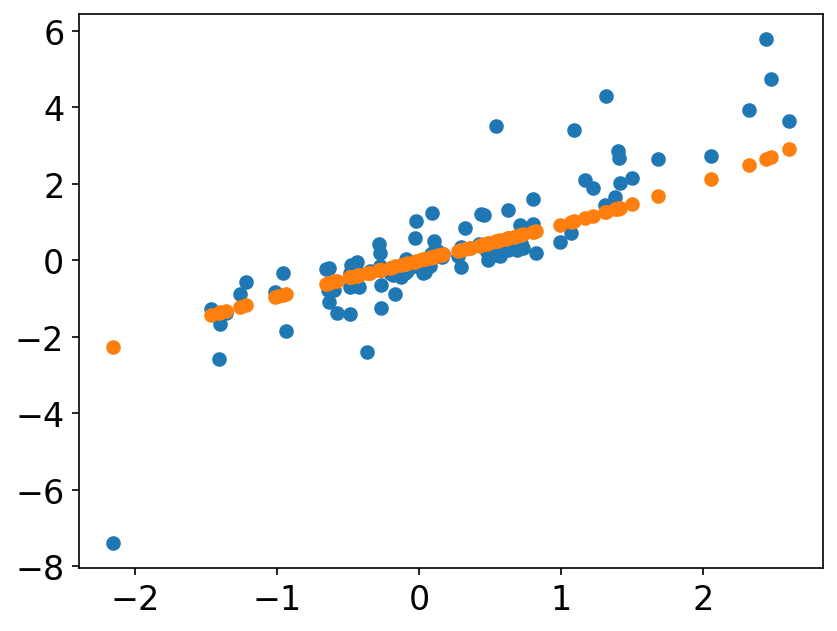

In [ ]:
X = torch.randn(100, d).to(device)
plt.scatter(X[:,0].detach().cpu().numpy(), model(X).detach().cpu().numpy().mean(axis=1))
plt.scatter(X[:,0].detach().cpu().numpy(), (X[:,0] + 0.074 * (X[:,0]**3 - 3*X[:,0]) / 6**0.5).detach().cpu().numpy())

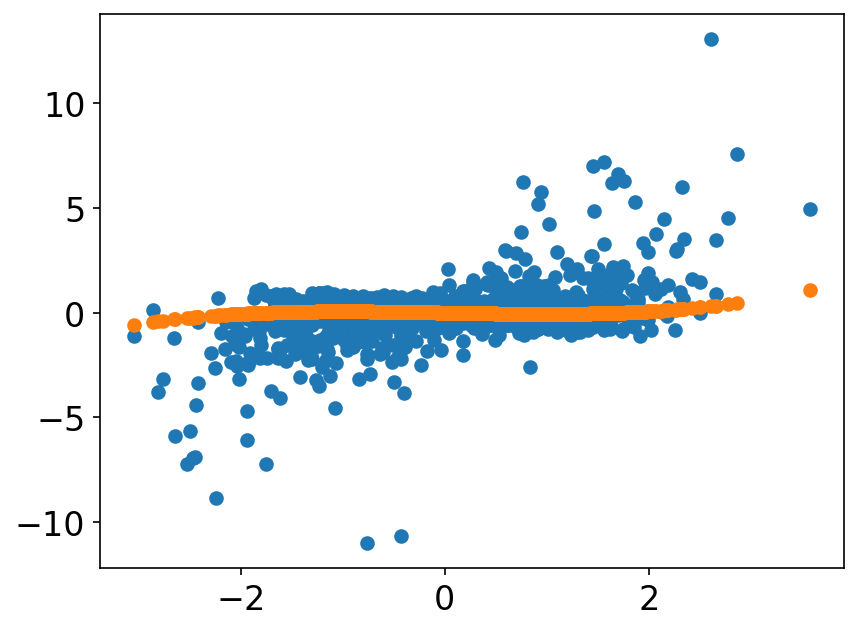

In [6]:
torch.manual_seed(213)
X = torch.randn(P, d).to(device)
He1 = X[:,0].detach().cpu().numpy()
cubic_component = model(X).detach().cpu().numpy().mean(axis=1) - He1
plt.scatter(X[:,0].detach().cpu().numpy(), cubic_component)
He3 = 0.074 * (X[:,0]**3 - 3*X[:,0]) / 6**0.5
plt.scatter(X[:,0].detach().cpu().numpy(), He3.detach().cpu().numpy())